# Modelling Income and Lifestyle Patterns in OKCupid Dating Profiles


In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error

from plot_style import set_plot_style


set_plot_style()

## Data Preparation

In [7]:
data_dir = "data/profiles.csv"

df = pd.read_csv(data_dir)

# select useful columns
cols = [
    "age", "height", "income",
    "diet", "drinks", "drugs",
    "smokes", "religion", "pets",
    "offspring", "education", "job"
]

data = df[cols]

# remove invalid income values
data = data[data["income"] >= 0]

# drop missing values
data = data.dropna()

# one-hot encode categorical variables
data_encoded = pd.get_dummies(data)

In [8]:
data_encoded

,age,height,income,diet_anything,diet_mostly anything,diet_mostly halal,diet_mostly kosher,diet_mostly other,diet_mostly vegan,diet_mostly vegetarian,...,job_military,job_other,job_political / government,job_rather not say,job_retired,job_sales / marketing / biz dev,job_science / tech / engineering,job_student,job_transportation,job_unemployed
1,35,70.0,80000,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
14,29,62.0,50000,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
72,35,73.0,150000,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
94,29,67.0,40000,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
113,23,66.0,20000,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59767,25,70.0,30000,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59789,42,70.0,150000,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59838,33,68.0,50000,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
59871,20,60.0,20000,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


# Feature Scaling

In [9]:
# normalize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

# PCA Analysis

In [20]:
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

In [21]:
print(pca.explained_variance_ratio_)


[0.02274305 0.0149779  0.01421704 0.01234878 0.01203055 0.01141023
 0.01122692 0.01095961 0.01081068 0.01055762 0.01037428 0.01033826
 0.01000598 0.00987923 0.00983257 0.00953331 0.00946088 0.00936341
 0.00916595 0.00907631]


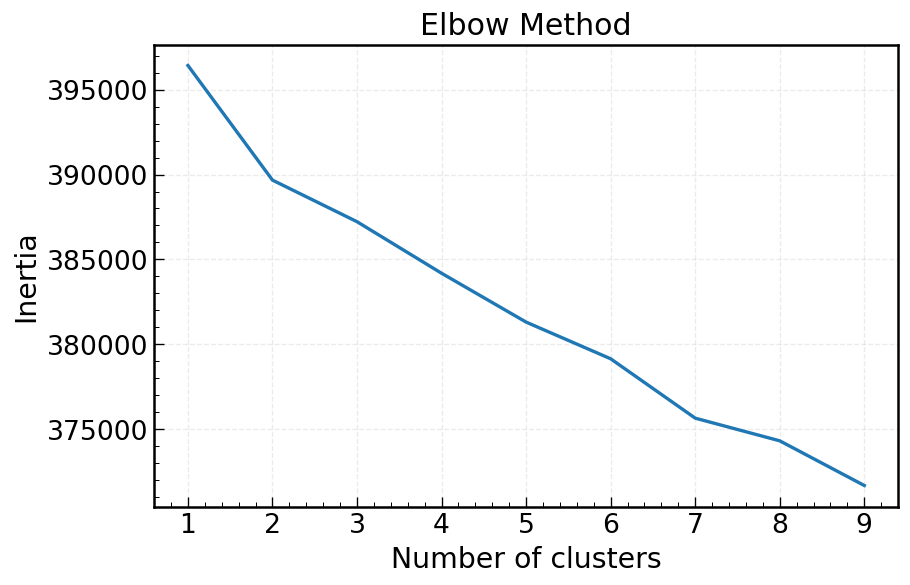

In [24]:

# Determine the number of k's I need

inertia = []

plt.figure()
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia)



plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_clustered = data.copy()
df_clustered["cluster"] = clusters


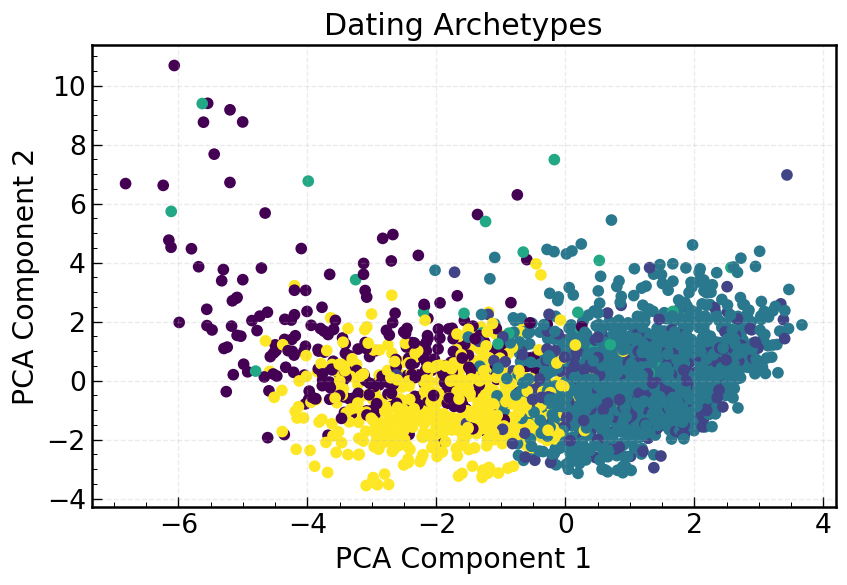

In [26]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Dating Archetypes")
plt.show()


In [27]:
df_clustered = data.copy()
df_clustered["cluster"] = clusters

print(df_clustered["cluster"].value_counts())



cluster
2    1359
5     531
1     310
0     281
3      27
4       1
Name: count, dtype: int64


In [29]:
cluster_summary = df_clustered.groupby("cluster").mean(numeric_only=True)
print(cluster_summary)

               age     height         income
cluster                                     
0        28.174377  69.562278  189252.669039
1        35.900000  67.909677   77193.548387
2        34.971302  68.700515   93392.200147
3        33.111111  68.333333  179259.259259
4        34.000000  70.000000  100000.000000
5        28.412429  69.320151   76497.175141


In [30]:
for c in range(len(set(clusters))):
    print("\nCluster", c)
    print(df_clustered[df_clustered["cluster"] == c]["job"].value_counts().head())



Cluster 0
job
artistic / musical / writer       53
other                             43
computer / hardware / software    25
hospitality / travel              23
science / tech / engineering      21
Name: count, dtype: int64

Cluster 1
job
other                             43
education / academia              32
artistic / musical / writer       27
medicine / health                 27
computer / hardware / software    24
Name: count, dtype: int64

Cluster 2
job
other                             159
science / tech / engineering      142
student                           139
computer / hardware / software    127
sales / marketing / biz dev       117
Name: count, dtype: int64

Cluster 3
job
other                             4
education / academia              3
computer / hardware / software    3
entertainment / media             3
executive / management            2
Name: count, dtype: int64

Cluster 4
job
computer / hardware / software    1
Name: count, dtype: int64

Cluster 5
job
othe